# Amatrice Paper Experiment Guide (TCN + Histogram Matching)

This notebook implements the full experiment workflow for the Amatrice paper using:

- **TCN (Temporal Convolutional Network)** as the sequence model
- **Histogram matching** preprocessing to remove systematic acquisition biases
- **NDI** and **log-NDI** scoring modes

| Run name | Feature | Model | Preprocessing | Scoring |
|---|---|---|---|---|
| `filt_fine_std_difference` | phase-STD | — (pre/post difference) | — | NDI |
| `filt_fine_cor_difference` | coherence | — (pre/post difference) | — | NDI |
| `tcn_notime_filt_fine_std_ndi` | phase-STD | TCN, no time | histogram match | NDI |
| `tcn_time_filt_fine_std_ndi` | phase-STD | TCN + time | histogram match | NDI |
| `tcn_time_filt_fine_std_logndi` | phase-STD | TCN + time | histogram match | log-NDI |
| `tcn_notime_filt_fine_cor_ndi` | coherence | TCN, no time | histogram match | NDI |
| `tcn_time_filt_fine_cor_ndi` | coherence | TCN + time | histogram match | NDI |
| `tcn_time_filt_fine_cor_logndi` | coherence | TCN + time | histogram match | log-NDI |

In [1]:
from pathlib import Path
import json
import os
import shlex
import subprocess

BASE_DIR = Path('/scratch/yangyanchen/amatrice2025/')
GEOM_REF_DIR = Path('/scratch/yangyanchen/amatrice2025/')
CROPPED_DIR = BASE_DIR / 'cropped_paper_bbox'
EVENT_DATE = '20160824'
NEXT_DATE = '20160821_20160914'
LAT_MIN, LAT_MAX = 42.6, 42.7
LON_MIN, LON_MAX = 13.2, 13.4


def run_cmd(cmd: str, env=None):
    print(f"[RUN] {cmd}")
    merged_env = os.environ.copy()
    merged_env['PYTHONUNBUFFERED'] = '1'
    if env:
        merged_env.update(env)

    proc = subprocess.Popen(
        cmd,
        shell=True,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        env=merged_env,
        bufsize=1,
    )
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end='')
    return_code = proc.wait()
    if return_code != 0:
        raise RuntimeError(f'Command failed with code {return_code}')


try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    DEVICE_NAME = torch.cuda.get_device_name(0) if GPU_AVAILABLE else 'CPU'
except Exception:
    GPU_AVAILABLE = False
    DEVICE_NAME = 'CPU'

print('BASE_DIR =', BASE_DIR)
print('CROPPED_DIR =', CROPPED_DIR)
print('EVENT_DATE =', EVENT_DATE)
print('NEXT_DATE =', NEXT_DATE)
print('Training device policy = CUDA if available else CPU')
print('Detected device =', DEVICE_NAME)

BASE_DIR = /scratch/yangyanchen/amatrice2025
CROPPED_DIR = /scratch/yangyanchen/amatrice2025/cropped_paper_bbox
EVENT_DATE = 20160824
NEXT_DATE = 20160821_20160914
Training device policy = CUDA if available else CPU
Detected device = NVIDIA A40


## 1. Crop interferogram pairs to the paper bounding box


In [ ]:
run_cmd(
    f"python -m insar_pipeline.app --step crop "
    f"--base-dir {BASE_DIR} "
    f"--geom-reference-dir {GEOM_REF_DIR} "
    f"--cropped-dir {CROPPED_DIR} "
    f"--output-dir {CROPPED_DIR} "
    f"--lat-min {LAT_MIN} --lat-max {LAT_MAX} "
    f"--lon-min {LON_MIN} --lon-max {LON_MAX}"
)

## 2. Generate INT-derived auxiliary products

Prepares the `filt_fine.std` and related auxiliary products from INT files.


In [ ]:
run_cmd(
    f"python -m insar_pipeline.app --step prepare_int_aux "
    f"--cropped-dir {CROPPED_DIR} "
    f"--output-dir {CROPPED_DIR} "
    f"--aux-corr-win 5 --aux-phsig-win 5 "
    f"--aux-variance-win 5 --aux-variance-looks 3"
)

## 3. Inspect prepared products


In [2]:
run_cmd(f"find {CROPPED_DIR} -maxdepth 1 -type f | sort")

[RUN] find /scratch/yangyanchen/amatrice2025/cropped_paper_bbox -maxdepth 1 -type f | sort
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.cor
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.cor.vrt
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.cor.xml
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.hdr
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.int
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.int.vrt
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.int.xml
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_fine.std
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_underamp_unfilt_fine_circ.cor
/scratch/yangyanchen/amatrice2025/cropped_paper_bbox/20160306_20160330_filt_underamp_unfilt_fine_circ.cor.v

## 4. Build datasets with histogram matching

Build RNN datasets for both `filt_fine.std` (phase-STD) and `filt_fine.cor` (coherence).
Histogram matching is applied to align the distribution of each time step to the median reference,
removing systematic acquisition-to-acquisition biases.


In [ ]:
# Build phase-STD dataset with histogram matching
run_cmd(
    f"python -m insar_pipeline.app --step build_dataset "
    f"--cropped-dir {CROPPED_DIR} --output-dir {CROPPED_DIR} "
    f"--event-date {EVENT_DATE} --observation-file filt_fine.std "
    f"--dataset-name dataset_rnn_filt_fine_std "
    f"--histogram-match --histogram-match-strategy median"
)

# Build coherence dataset with histogram matching
run_cmd(
    f"python -m insar_pipeline.app --step build_dataset "
    f"--cropped-dir {CROPPED_DIR} --output-dir {CROPPED_DIR} "
    f"--event-date {EVENT_DATE} --observation-file filt_fine.cor "
    f"--dataset-name dataset_rnn_filt_fine_cor "
    f"--histogram-match --histogram-match-strategy median"
)

run_cmd(
    f"python -m insar_pipeline.app --step validate_dataset "
    f"--output-dir {CROPPED_DIR}"
)

## 5. Pre/post NDI difference baselines

Simple normalized difference index between the last pre-event and first post-event observation.
No model is used — this is the traditional baseline.


In [ ]:
import numpy as np
from pathlib import Path
from insar_pipeline.scoring import calculate_difference

PREDICT_DIR = CROPPED_DIR / 'predict'
PREDICT_DIR.mkdir(parents=True, exist_ok=True)

def compute_prepost_ndi(dataset_dir: Path, observation_file: str, metric: str, output_name: str):
    """Load the score observation (post-event) and the last training image (pre-event),
    compute normalized difference, and save to PREDICT_DIR."""
    # Score observation = post-event
    obs_candidates = ['score_observation_std.npy', 'geninue_std.npy'] if metric == 'phase_std'         else ['score_observation.npy', 'geninue.npy']
    obs_file = next((dataset_dir / n for n in obs_candidates if (dataset_dir / n).exists()), None)
    if obs_file is None:
        print(f'WARNING: score observation not found in {dataset_dir}')
        return

    # Last time step in training series = pre-event
    ts_candidates = ['rnn_data_std.npy', 'data_std.npy'] if metric == 'phase_std'         else ['rnn_data.npy', 'data.npy']
    ts_file = next((dataset_dir / n for n in ts_candidates if (dataset_dir / n).exists()), None)
    if ts_file is None:
        print(f'WARNING: timeseries not found in {dataset_dir}')
        return

    post_event = np.load(obs_file).squeeze().astype(np.float32)
    timeseries = np.load(ts_file)
    pre_event = timeseries[:, :, -1].astype(np.float32)

    score = calculate_difference(pre_event, post_event, metric=metric)
    out_path = PREDICT_DIR / output_name
    np.save(out_path, score)
    print(f'Saved baseline NDI: {out_path}  shape={score.shape}')


compute_prepost_ndi(
    dataset_dir=CROPPED_DIR / 'dataset_rnn_filt_fine_std',
    observation_file='filt_fine.std',
    metric='phase_std',
    output_name='filt_fine_std_difference_score.npy',
)

compute_prepost_ndi(
    dataset_dir=CROPPED_DIR / 'dataset_rnn_filt_fine_cor',
    observation_file='filt_fine.cor',
    metric='coherence',
    output_name='filt_fine_cor_difference_score.npy',
)

## 6. TCN training and NDI scoring

Train a TCN model for each combination of metric × timestamp mode, then compute NDI scores.

- Uses **Huber loss** (robust to outlier pixels in SAR data)
- Uses **AdamW** optimizer with weight decay for better generalisation
- Uses 30 epochs with early stopping


In [ ]:
TCN_EXPERIMENTS = [
    {
        'observation_file': 'filt_fine.std',
        'metric': 'phase_std',
        'dataset_name': 'dataset_rnn_filt_fine_std',
        'timestamp_modes': ['time', 'notime'],
    },
    {
        'observation_file': 'fine.cor.full',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_fine_cor_full',
        'timestamp_modes': ['time'],
    },
    {
        'observation_file': 'filt_fine.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_filt_fine_cor',
        'timestamp_modes': ['time'],
    },
    {
        'observation_file': 'unfilt_fine.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_unfilt_fine_cor',
        'timestamp_modes': ['time'],
    },
    {
        'observation_file': 'underamp_unfilt_fine.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_underamp_unfilt_fine_cor',
        'timestamp_modes': ['time'],
    },
    {
        'observation_file': 'underamp_unfilt_fine_circ.cor',
        'metric': 'coherence',
        'dataset_name': 'dataset_rnn_underamp_unfilt_fine_circ_cor',
        'timestamp_modes': ['time'],
    },
]

for exp in TCN_EXPERIMENTS:
    for timestamp_flag in exp['timestamp_modes']:
        disable = '--disable-timestamp' if timestamp_flag == 'notime' else ''
        metric_tag = exp['metric']
        time_tag = timestamp_flag
        dataset_dir = CROPPED_DIR / exp['dataset_name']

        print('\n' + '=' * 80)
        print(f'TCN training: metric={metric_tag} timestamp={time_tag}')
        print('=' * 80)

        # Train
        run_cmd(
            f"python -m insar_pipeline.app --step train_predict "
            f"--dataset-dir {dataset_dir} "
            f"--output-dir {CROPPED_DIR} "
            f"--next-date {NEXT_DATE} "
            f"--timeseries-metric {metric_tag} "
            f"--ts-model tcn "
            f"--loss-type huber "
            f"--optimizer adamw --weight-decay 1e-4 "
            f"--epochs 30 "
            f"--rnn-hidden-dim 64 --rnn-num-layers 3 "
            f"{disable}"
        )

        # Score (NDI)
        score_filename = f"tcn_{time_tag}_{exp['observation_file'].replace('.','_')}_ndi_score.npy"
        run_cmd(
            f"python -m insar_pipeline.app --step score "
            f"--dataset-dir {dataset_dir} "
            f"--output-dir {CROPPED_DIR} "
            f"--timeseries-metric {metric_tag} "
            f"--ts-model tcn "
            f"--score-mode ndi "
            f"--score-filename {score_filename} "
            f"{disable}"
        )
        print(f'NDI score saved: predict/{score_filename}')


TCN training: metric=phase_std timestamp=time
[RUN] python -m insar_pipeline.app --step train_predict --dataset-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/dataset_rnn_filt_fine_std --output-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox --next-date 20160821_20160914 --timeseries-metric phase_std --ts-model tcn --loss-type huber --optimizer adamw --weight-decay 1e-4 --epochs 30 --rnn-hidden-dim 64 --rnn-num-layers 3 

[SARcoherenceDPM v0.3.0] [STEP] train_predict
  - dataset_dir: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/dataset_rnn_filt_fine_std
  - artifact_prefix: rnn_tcn_phase_std_raw_time
  - param_file: None
  - model: tcn
  - metric: phase_std
  - timestamp: enabled
  - device_policy: cuda-if-available-else-cpu
  - epochs: 30
  - train_batch_size: 128
  - pred_batch_size: 256
  - lr: 0.001
  - rnn_hidden_dim: 64
  - rnn_num_layers: 3
  - rnn_dropout: 0.1
  - optimizer: adamw
  - weight_decay: 0.0001
  - max_grad_norm: None
[RNN] loading_timeser

## 7. TCN log-NDI scoring

Reuse the predictions from Section 6 (no retraining needed).
log-NDI = log(observed / predicted) for phase_std, log(predicted / observed) for coherence.
A positive value indicates damage.


In [3]:
for exp in TCN_EXPERIMENTS:
    for timestamp_flag in exp['timestamp_modes']:
        disable = '--disable-timestamp' if timestamp_flag == 'notime' else ''
        metric_tag = exp['metric']
        time_tag = timestamp_flag
        dataset_dir = CROPPED_DIR / exp['dataset_name']

        print('\n' + '-' * 80)
        print(f'TCN log-NDI scoring: metric={metric_tag} timestamp={time_tag}')

        score_filename = f"tcn_{time_tag}_{exp['observation_file'].replace('.','_')}_logndi_score.npy"
        run_cmd(
            f"python -m insar_pipeline.app --step score "
            f"--dataset-dir {dataset_dir} "
            f"--output-dir {CROPPED_DIR} "
            f"--timeseries-metric {metric_tag} "
            f"--ts-model tcn "
            f"--score-mode log_ndi "
            f"--score-filename {score_filename} "
            f"{disable}"
        )
        print(f'log-NDI score saved: predict/{score_filename}')


--------------------------------------------------------------------------------
TCN log-NDI scoring: metric=phase_std timestamp=time
[RUN] python -m insar_pipeline.app --step score --dataset-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/dataset_rnn_filt_fine_std --output-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox --timeseries-metric phase_std --ts-model tcn --score-mode log_ndi --score-filename tcn_time_filt_fine_std_logndi_score.npy 

[SARcoherenceDPM v0.3.0] [STEP] score
  - dataset_dir: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/dataset_rnn_filt_fine_std
  - predict_dir: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/predict
  - artifact_prefix: rnn_tcn_phase_std_raw_time
  - score_filename: tcn_time_filt_fine_std_logndi_score.npy
  - score_path: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/predict/tcn_time_filt_fine_std_logndi_score.npy
log-NDI score saved: predict/tcn_time_filt_fine_std_logndi_score.npy

--------------------------

In [4]:
run_cmd(
    f"python -m insar_pipeline.app --step output "
    f"--predict-dir {CROPPED_DIR / 'predict'} "
    f"--output-dir {CROPPED_DIR} "
    f"--lat-file {CROPPED_DIR / 'lat_cropped.rdr'} "
    f"--lon-file {CROPPED_DIR / 'lon_cropped.rdr'} "
    f"--subset-params '-l 42.6 42.7 -L 13.2 13.4'"
)


[RUN] python -m insar_pipeline.app --step output --predict-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/predict --output-dir /scratch/yangyanchen/amatrice2025/cropped_paper_bbox --lat-file /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/lat_cropped.rdr --lon-file /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/lon_cropped.rdr --subset-params '-l 42.6 42.7 -L 13.2 13.4'

[SARcoherenceDPM v0.3.0] [STEP] output
write file: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/predict/tcn_notime_filt_fine_std_logndi.cor
write file: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/predict/tcn_notime_filt_fine_std_logndi.cor.xml
write file: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/predict/tcn_notime_filt_fine_std_logndi.cor.vrt
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /scratch/yangyanchen/amatrice2025/cropped_paper_bbox/lat_cropped.rdr
calculate output pixel size using approach 1 (

## 8. AUC evaluation

Load all score maps and compute AUC against the ground-truth damage mask.
`DAMAGE_MASK_FILE` should be a binary `.npy` array (1 = damaged, 0 = undamaged) spatially aligned with the score maps.


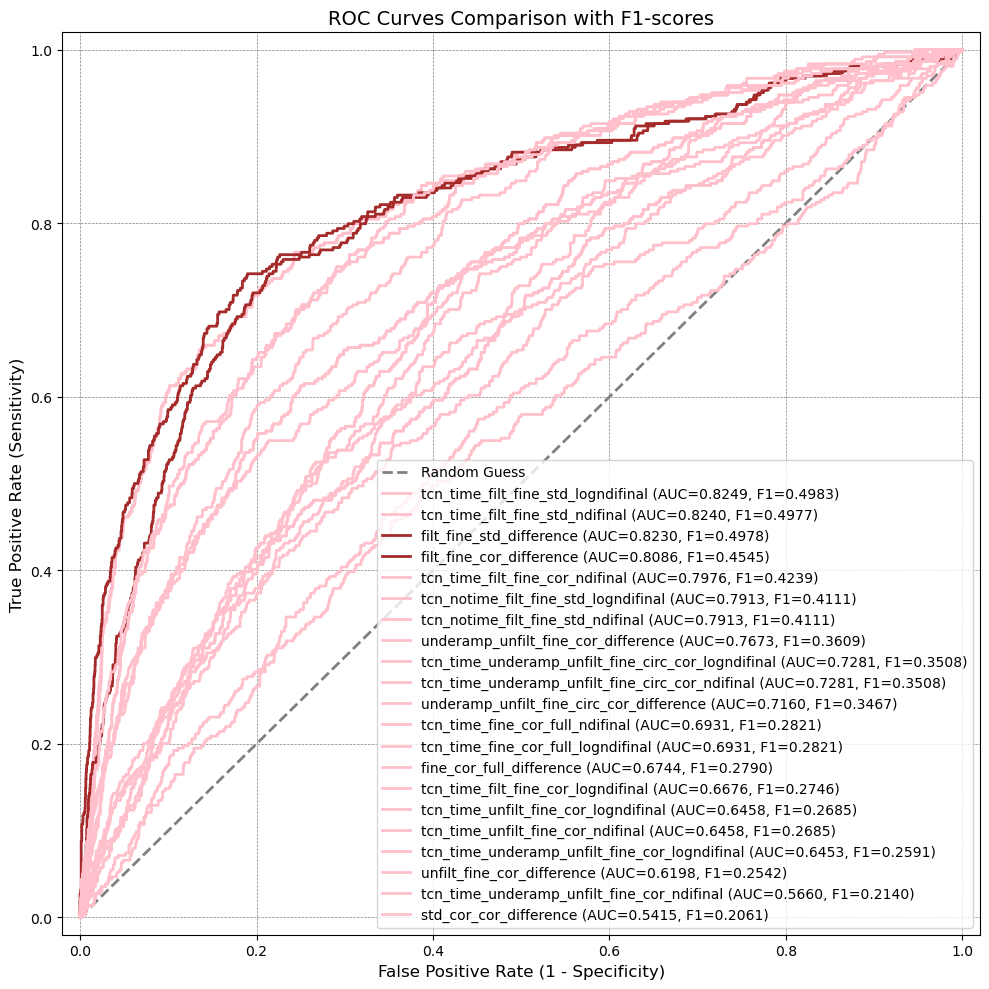


特征性能报告:
按AUC值降序排列，显示最佳F1-score及对应的阈值和虚警率(FPR)
----------------------------------------------------------------------------------------------------
特征名称         AUC值         最佳F1-score      阈值              虚警率(FPR)       
----------------------------------------------------------------------------------------------------
tcn_time_filt_fine_std_logndifinal 0.82495      0.49830         0.81094         0.09774        
tcn_time_filt_fine_std_ndifinal 0.82404      0.49774         0.38462         0.09807        
filt_fine_std_difference 0.82303      0.49784         0.57827         0.05165        
filt_fine_cor_difference 0.80863      0.45445         0.34531         0.12782        
tcn_time_filt_fine_cor_ndifinal 0.79762      0.42389         0.36299         0.10101        
tcn_notime_filt_fine_std_logndifinal 0.79130      0.41106         1.16351         0.09709        
tcn_notime_filt_fine_std_ndifinal 0.79129      0.41106         0.52394         0.09709        
underamp_unfilt_fine_cor_diffe

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix

df = pd.read_csv("/scratch/yangyanchen/amatrice2025/timeseries.csv")  # 替换为你的文件路径

# 定义特征列表和颜色配置 decorrelation	TGRS_std	TGRS


features = features = [
    ("filt_fine_cor_difference", "brown"),
    ("filt_fine_std_difference", "brown"),
    ("fine_cor_full_difference", "pink"),
    ("std_cor_cor_difference", "pink"),
    ("underamp_unfilt_fine_circ_cor_difference", "pink"),
    ("underamp_unfilt_fine_cor_difference", "pink"),
    ("unfilt_fine_cor_difference", "pink"),
    ("tcn_notime_filt_fine_std_logndifinal", "pink"),
    ("tcn_notime_filt_fine_std_ndifinal", "pink"),
    ("tcn_time_filt_fine_cor_logndifinal", "pink"),
    ("tcn_time_filt_fine_cor_ndifinal", "pink"),
    ("tcn_time_filt_fine_std_logndifinal", "pink"),
    ("tcn_time_filt_fine_std_ndifinal", "pink"),
    ("tcn_time_fine_cor_full_logndifinal", "pink"),
    ("tcn_time_fine_cor_full_ndifinal", "pink"),
    ("tcn_time_underamp_unfilt_fine_circ_cor_logndifinal", "pink"),
    ("tcn_time_underamp_unfilt_fine_circ_cor_ndifinal", "pink"),
    ("tcn_time_underamp_unfilt_fine_cor_logndifinal", "pink"),
    ("tcn_time_underamp_unfilt_fine_cor_ndifinal", "pink"),
    ("tcn_time_unfilt_fine_cor_logndifinal", "pink"),
    ("tcn_time_unfilt_fine_cor_ndifinal", "pink")
]
# 设置画布
plt.figure(figsize=(10, 10))

# 绘制参考线
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', label='Random Guess')

# 创建列表存储计算结果
roc_data = []
f1_results = []  # 存储F1-score结果

# 先计算所有特征的AUC值和F1-score
for feature, color in features:
    y_true = df['damaged']
    y_score = df[feature]
    
    # 计算ROC曲线
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # 找到最佳F1-score及其阈值
    best_f1 = 0
    best_threshold = 0
    best_fpr = 0
    best_f1_index = 0
    
    # 遍历所有阈值计算F1-score
    for i, threshold in enumerate(thresholds):
        # 使用当前阈值进行预测
        y_pred = (y_score >= threshold).astype(int)
        
        # 计算F1-score
        f1 = f1_score(y_true, y_pred)
        
        # 更新最佳F1-score
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_f1_index = i
    
    # 获取最佳阈值对应的虚警率(FPR)
    if best_f1_index < len(fpr):
        best_fpr = fpr[best_f1_index]
    else:
        # 如果索引越界，使用上一个可用的FPR值
        best_fpr = fpr[-1] if fpr.size > 0 else 0
    
    # 存储特征名、颜色、AUC值以及ROC曲线数据
    roc_data.append({
        'feature': feature,
        'color': color,
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'best_f1': best_f1,
        'best_threshold': best_threshold,
        'best_fpr': best_fpr
    })
    
    # 存储F1结果用于后续输出
    f1_results.append({
        'feature': feature,
        'auc': roc_auc,
        'best_f1': best_f1,
        'threshold': best_threshold,
        'fpr': best_fpr
    })

# 按AUC值从高到低排序
roc_data_sorted = sorted(roc_data, key=lambda x: x['auc'], reverse=True)

# 按排序后的顺序绘制ROC曲线
for data in roc_data_sorted:
    plt.plot(data['fpr'], data['tpr'], color=data['color'], lw=2,
             label=f"{data['feature']} (AUC={data['auc']:.4f}, F1={data['best_f1']:.4f})")

# 图表装饰
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves Comparison with F1-scores', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig('ROC_curves_with_F1_scores.png', dpi=300)
plt.show()

# 打印F1-score和虚警率结果
print("\n特征性能报告:")
print("按AUC值降序排列，显示最佳F1-score及对应的阈值和虚警率(FPR)")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

# 按AUC排序F1结果
f1_results_sorted = sorted(f1_results, key=lambda x: x['auc'], reverse=True)

for result in f1_results_sorted:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))

# 按F1-score排序
f1_results_sorted_by_f1 = sorted(f1_results, key=lambda x: x['best_f1'], reverse=True)

print("\n按F1-score排序:")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

for result in f1_results_sorted_by_f1:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))
# 按虚警率(FPR)排序（升序，即FPR越小越好）
f1_results_sorted_by_fpr = sorted(f1_results, key=lambda x: x['fpr'])

print("\n按虚警率(FPR)排序（从小到大）:")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

for result in f1_results_sorted_by_fpr:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))
